In [27]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import os
import joblib

In [ ]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=932&path=url_spam.csv"
df = pd.read_csv(url)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   url      2999 non-null   object
 1   is_spam  2999 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 26.5+ KB


In [10]:
df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


In [ ]:
def clean_url(url):
    tokens = re.split(r'\W+', url.lower())
    stopwords = {"http", "https", "www", "com"}
    tokens = [t for t in tokens if t and t not in stopwords]
    return " ".join(tokens)

df["clean_url"] = df["url"].apply(clean_url)
df["is_spam"] = df["is_spam"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_url"], df["is_spam"], test_size=0.2, random_state=42, stratify=df["is_spam"]
)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [15]:
param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"],
    "kernel": ["linear", "rbf"]
}

grid = GridSearchCV(SVC(), param_grid, cv=3, verbose=2, n_jobs=-1)
grid.fit(X_train_vec, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor score:", grid.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.8s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.7s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=   0.7s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   1.1s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.8s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=   0.8s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time=   0.6s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=   0.7s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   1.3s[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   1.3s

[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time=   0.5s
[CV] END ......................C=0.1, gamma=auto

In [16]:
print(df[["url", "clean_url", "is_spam"]].head(10))

                                                 url  \
0  https://briefingday.us8.list-manage.com/unsubs...   
1                             https://www.hvper.com/   
2                 https://briefingday.com/m/v4n3i4f3   
3   https://briefingday.com/n/20200618/m#commentform   
4                        https://briefingday.com/fan   
5  https://www.brookings.edu/interactives/reopeni...   
6  https://www.reuters.com/investigates/special-r...   
7  https://www.theatlantic.com/magazine/archive/2...   
8  https://www.vox.com/2020/6/17/21294680/john-bo...   
9  https://www.theguardian.com/travel/2020/jun/18...   

                                           clean_url  is_spam  
0            briefingday us8 list manage unsubscribe        1  
1                                              hvper        1  
2                             briefingday m v4n3i4f3        1  
3               briefingday n 20200618 m commentform        0  
4                                    briefingday fan        1  

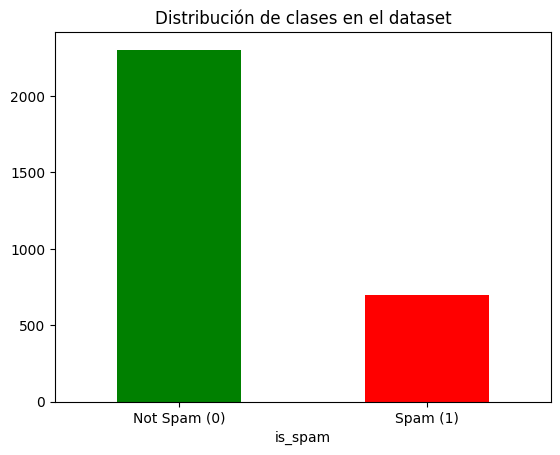

In [18]:
df["is_spam"].value_counts().plot(kind="bar", color=["green", "red"])
plt.xticks([0, 1], ["Not Spam (0)", "Spam (1)"], rotation=0)
plt.title("Distribución de clases en el dataset")
plt.show()

In [19]:
svm = SVC()
svm.fit(X_train_vec, y_train)

y_pred = svm.predict(X_test_vec)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       461
           1       0.95      0.87      0.91       139

    accuracy                           0.96       600
   macro avg       0.95      0.93      0.94       600
weighted avg       0.96      0.96      0.96       600

[[454   7]
 [ 18 121]]


In [ ]:
save_dir = "/home/kass/machine-learning-python-template/models/ML_NLP"

joblib.dump(grid.best_estimator_, os.path.join(save_dir, "url_spam_svm.pkl"))
joblib.dump(vectorizer, os.path.join(save_dir, "url_spam_tfidf.pkl"))

print("Modelo y vectorizador guardados en", save_dir)

✅ Modelo y vectorizador guardados en /home/kass/machine-learning-python-template/models/ML_NLP
